# 🌀 Basin Generalisation for Tropical Cyclone Prediction
## PhysIRM: Physics-guided Invariant Risk Minimization

**R&D Notebook** — Cell-by-cell experimentation with proper ablation study.

---

In [1]:
import os, glob, math, time, warnings, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from netCDF4 import Dataset as NC4Dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.autograd import grad
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
matplotlib.rcParams['figure.dpi'] = 120

# ── Paths & Constants ─────────────────────────────────────────────────────────
PROJECT_ROOT = Path('/Users/thiruanand/MLfTCC')
DATA_ROOT    = PROJECT_ROOT / 'Notebooks' / 'data' / 'tropicyclonenet' / 'TCND_test'
BASINS = ['EP', 'NA', 'NI', 'SI', 'SP', 'WP']
BASIN_FULL = {'EP':'Eastern Pacific','NA':'North Atlantic','NI':'North Indian',
              'SI':'South Indian','SP':'South Pacific','WP':'Western Pacific'}
INT_NAMES = ['Rapid Weakening','Weakening','Steady','Intensification','Rapid Intensification']
DIR_NAMES = ['E','NE','N','NW','W','SW','S','SE']
RI_CLASS = 4

# Device
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42; torch.manual_seed(SEED); np.random.seed(SEED)

print(f"✓ Setup | Device: {DEVICE} | PyTorch: {torch.__version__} | Data: {DATA_ROOT.exists()}")


✓ Setup | Device: mps | PyTorch: 2.10.0 | Data: True


## 1. Data Loading
Parse Data1D (track), Data3D (ERA5 NetCDF), Env-Data (.npy) across all 6 basins.

In [2]:
def parse_data1d(data_root, basins):
    records = []
    for basin in basins:
        d = data_root / 'Data1D' / basin / 'test'
        if not d.exists(): continue
        for f in sorted(d.glob('*.txt')):
            try:
                df = pd.read_csv(f, sep='\t', header=None,
                    names=['ID','col1','LONG_norm','LAT_norm','PRES_norm','WND_norm','datetime','name'])
                for _, r in df.iterrows():
                    records.append({'basin':basin, 'storm_name':str(r['name']).strip(),
                        'timestep':int(r['ID']), 'datetime':str(int(r['datetime'])),
                        'long_norm':float(r['LONG_norm']), 'lat_norm':float(r['LAT_norm']),
                        'pres_norm':float(r['PRES_norm']), 'wnd_norm':float(r['WND_norm'])})
            except: pass
    return pd.DataFrame(records)

def scan_files(data_root, basins, subdir, ext):
    idx = {}
    for b in basins:
        d = data_root / subdir / b
        if not d.exists(): continue
        for f in sorted(d.rglob(f'*{ext}')):
            storm = f.parent.name if ext=='.npy' else f.stem.split('_')[1]
            dt = f.stem if ext=='.npy' else f.stem.split('_')[2]
            idx[(b, storm, dt)] = str(f)
    return idx

def build_env_vector(env_dict):
    def to_scalar(x):
        return np.float32(np.argmax(x)) if isinstance(x, np.ndarray) else np.float32(max(x, 0))
    return np.concatenate([
        np.array(env_dict.get('month', np.zeros(12)), dtype=np.float32),
        np.array(env_dict.get('area', np.zeros(6)), dtype=np.float32),
        np.array(env_dict.get('intensity_class', np.zeros(6)), dtype=np.float32),
        np.array([env_dict.get('wind', 0)], dtype=np.float32),
        np.array([env_dict.get('move_velocity', 0)], dtype=np.float32),
        np.array(env_dict.get('location_long', np.zeros(36)), dtype=np.float32),
        np.array(env_dict.get('location_lat', np.zeros(12)), dtype=np.float32),
        np.array([to_scalar(env_dict.get('history_direction12',-1))], dtype=np.float32),
        np.array([to_scalar(env_dict.get('history_direction24',-1))], dtype=np.float32),
        np.array([to_scalar(env_dict.get('history_inte_change24',-1))], dtype=np.float32),
    ])  # → (77,)

def load_data3d(nc_path):
    """Load Data3D with proper handling of masked SST and per-channel normalization."""
    with NC4Dataset(nc_path, 'r') as nc:
        u = np.array(nc.variables['u'][:], dtype=np.float32)
        v = np.array(nc.variables['v'][:], dtype=np.float32)
        z_geo = np.array(nc.variables['z'][:], dtype=np.float32)
        sst_var = nc.variables['sst']
        # Handle masked arrays (SST has fill values ~1e37 over land)
        sst_raw = np.ma.filled(sst_var[:], fill_value=np.nan).astype(np.float32)
    chs = [u[0,i] for i in range(4)] + [v[0,i] for i in range(4)] + [z_geo[0,i] for i in range(4)]
    chs.append(sst_raw[0] if sst_raw.ndim==3 else sst_raw)
    data_3d = np.stack(chs, axis=0)
    # Per-channel normalization (critical: geopotential ~5k-123k, SST ~280-310K)
    for c in range(13):
        ch = data_3d[c]
        valid = ch[~np.isnan(ch)]
        if len(valid) > 0:
            mu, std = valid.mean(), max(valid.std(), 1e-6)
            ch[np.isnan(ch)] = mu
            data_3d[c] = (ch - mu) / std
        else:
            data_3d[c] = np.zeros_like(ch)
    return data_3d  # (13, 81, 81), normalized

# Build labeled dataset with intensity & direction targets
def compute_labeled_dataset(data_root, basins):
    records = []
    d3d_idx = scan_files(data_root, basins, 'Data3D', '.nc')
    env_idx = scan_files(data_root, basins, 'Env-Data', '.npy')
    for basin in basins:
        d = data_root / 'Data1D' / basin / 'test'
        if not d.exists(): continue
        for f in sorted(d.glob('*.txt')):
            try:
                df = pd.read_csv(f, sep='\t', header=None,
                    names=['ID','col1','LONG_norm','LAT_norm','PRES_norm','WND_norm','datetime','name'])
                n = len(df)
                for i in range(n):
                    r = df.iloc[i]; dt = str(int(r['datetime']))
                    storm = str(r['name']).strip()
                    if i+4 >= n: continue
                    dw = df.iloc[i+4]['WND_norm'] - r['WND_norm']
                    y_int = 0 if dw<=-0.27 else 1 if dw<=-0.09 else 2 if dw<=0.09 else 3 if dw<=0.27 else 4
                    dx = df.iloc[i+4]['LONG_norm']-r['LONG_norm']
                    dy = df.iloc[i+4]['LAT_norm']-r['LAT_norm']
                    ang = math.atan2(dy,dx); ang = ang+2*math.pi if ang<0 else ang
                    y_dir = min(int(((ang+math.pi/8)%(2*math.pi))/(math.pi/4)),7)
                    d3d_p = d3d_idx.get((basin,storm.upper(),dt)) or d3d_idx.get((basin,storm,dt))
                    env_p = env_idx.get((basin,storm.upper(),dt)) or env_idx.get((basin,storm,dt))
                    if not (d3d_p and env_p): continue
                    records.append({'basin':basin,'storm':storm,'datetime':dt,
                        'data1d':np.array([r['LONG_norm'],r['LAT_norm'],r['PRES_norm'],r['WND_norm']],dtype=np.float32),
                        'data3d_path':d3d_p,'env_path':env_p,'y_intensity':y_int,'y_direction':y_dir})
            except: pass
    return records

print("Building labeled dataset (this takes ~30s)...")
t0 = time.time()
ALL_SAMPLES = compute_labeled_dataset(DATA_ROOT, BASINS)
print(f"✓ {len(ALL_SAMPLES):,} samples in {time.time()-t0:.1f}s")
basin_counts = Counter(s['basin'] for s in ALL_SAMPLES)
for b in BASINS:
    ri = sum(1 for s in ALL_SAMPLES if s['basin']==b and s['y_intensity']==4)
    print(f"  {b}: {basin_counts[b]:5d} | RI: {ri:3d} ({100*ri/max(basin_counts[b],1):.1f}%)")


Building labeled dataset (this takes ~30s)...
✓ 14,158 samples in 1.7s
  EP:  2929 | RI: 564 (19.3%)
  NA:  3468 | RI: 631 (18.2%)
  NI:   447 | RI: 140 (31.3%)
  SI:  2530 | RI: 475 (18.8%)
  SP:   802 | RI: 217 (27.1%)
  WP:  3982 | RI: 790 (19.8%)


## 2. Exploratory Data Analysis

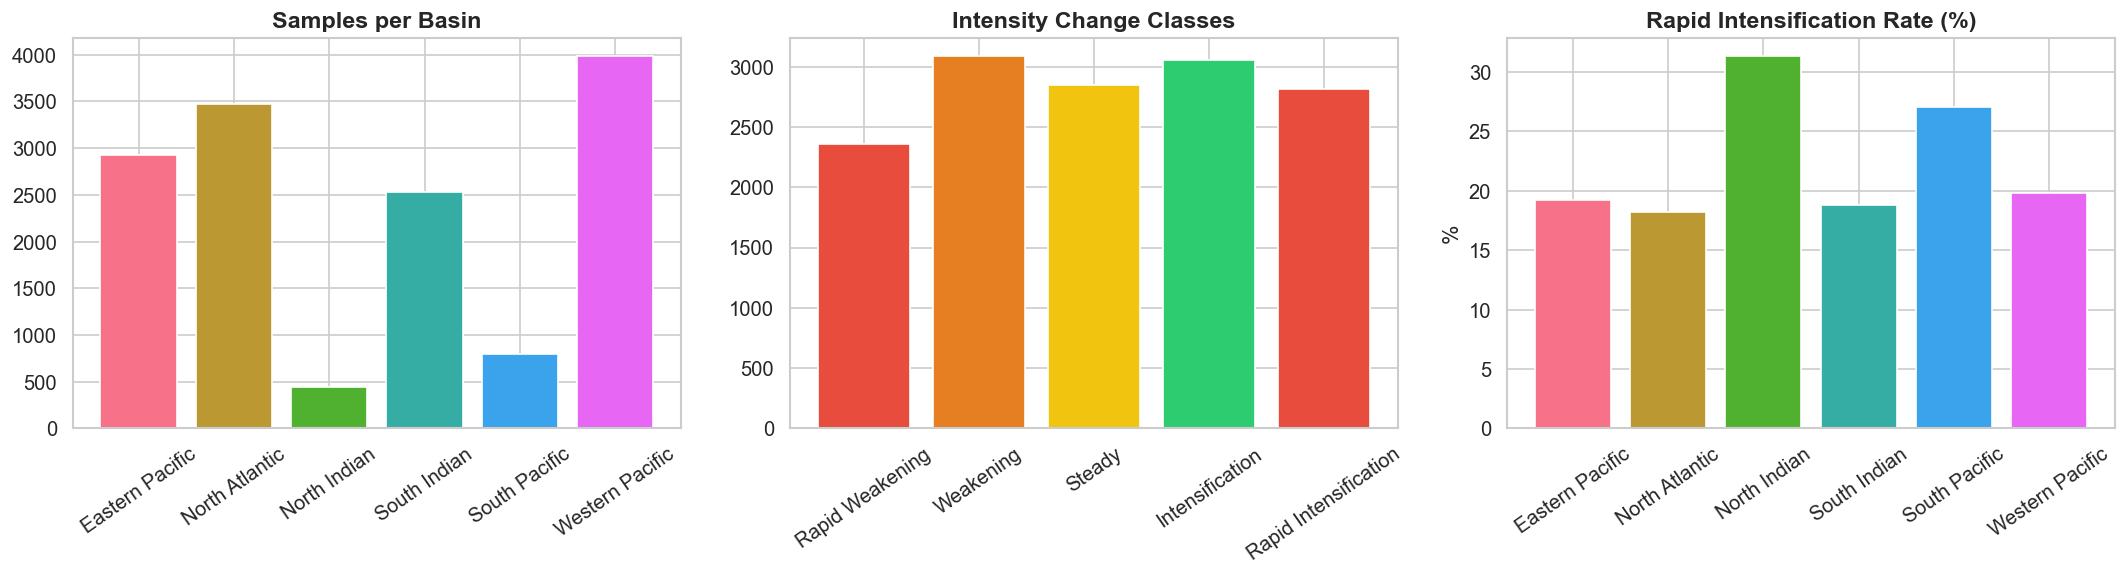

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Basin distribution
basin_counts = Counter(s['basin'] for s in ALL_SAMPLES)
colors = sns.color_palette('husl', 6)
axes[0].bar([BASIN_FULL[b] for b in BASINS], [basin_counts[b] for b in BASINS], color=colors)
axes[0].set_title('Samples per Basin', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

# Intensity class distribution
int_counts = Counter(s['y_intensity'] for s in ALL_SAMPLES)
axes[1].bar(INT_NAMES, [int_counts[i] for i in range(5)],
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#e74c3c'])
axes[1].set_title('Intensity Change Classes', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)

# RI rate per basin
ri_rates = []
for b in BASINS:
    total = sum(1 for s in ALL_SAMPLES if s['basin']==b)
    ri = sum(1 for s in ALL_SAMPLES if s['basin']==b and s['y_intensity']==4)
    ri_rates.append(100*ri/max(total,1))
axes[2].bar([BASIN_FULL[b] for b in BASINS], ri_rates, color=colors)
axes[2].set_title('Rapid Intensification Rate (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout(); plt.show()


## 3. PyTorch Dataset & DataLoaders
With basin-stratified LOBO splits.

In [4]:
class TCNDDataset(Dataset):
    """TCND dataset for basin generalisation experiments."""
    def __init__(self, samples, use_3d=True, use_env=True):
        self.samples = samples
        self.use_3d = use_3d
        self.use_env = use_env
        self.basin_to_idx = {b:i for i,b in enumerate(BASINS)}

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        item = {
            'data_1d': torch.tensor(s['data1d'], dtype=torch.float32),
            'y_intensity': torch.tensor(s['y_intensity'], dtype=torch.long),
            'y_direction': torch.tensor(s['y_direction'], dtype=torch.long),
            'basin_idx': torch.tensor(self.basin_to_idx[s['basin']], dtype=torch.long),
        }
        if self.use_3d:
            item['data_3d'] = torch.tensor(load_data3d(s['data3d_path']), dtype=torch.float32)
        else:
            item['data_3d'] = torch.zeros(13, 81, 81)  # placeholder

        if self.use_env:
            env = np.load(s['env_path'], allow_pickle=True).item()
            item['env_data'] = torch.tensor(build_env_vector(env), dtype=torch.float32)
        else:
            item['env_data'] = torch.zeros(77)

        # Physics features (8-dim): approximate from available data
        env_d = np.load(s['env_path'], allow_pickle=True).item() if self.use_env else {}
        sst_anom = s['data1d'][3] * 0.5  # proxy from wind
        wind_shear = abs(s['data1d'][2] - s['data1d'][3])
        lat_rad = abs(s['data1d'][1]) * 0.3
        coriolis = 2 * 7.2921e-5 * np.sin(np.clip(lat_rad, -np.pi/2, np.pi/2))
        mpi_proxy = max(0, sst_anom * 2 - wind_shear)
        bl_moisture = max(0, 1.0 - abs(s['data1d'][2]))
        outflow_temp = -0.5 * abs(s['data1d'][1])
        steering = s['data1d'][0] * 0.1
        current_int = s['data1d'][3]
        item['phys_features'] = torch.tensor(
            [sst_anom, wind_shear, coriolis, mpi_proxy,
             bl_moisture, outflow_temp, steering, current_int],
            dtype=torch.float32)
        return item

def make_lobo_split(all_samples, target_basin, val_frac=0.15):
    """Leave-One-Basin-Out: source = all except target, target = held-out."""
    source = [s for s in all_samples if s['basin'] != target_basin]
    target = [s for s in all_samples if s['basin'] == target_basin]
    # Split source into train/val
    np.random.shuffle(source)
    n_val = int(len(source) * val_frac)
    return source[n_val:], source[:n_val], target

def make_per_basin_loaders(samples, batch_size=32, use_3d=True, use_env=True):
    """Create per-basin DataLoaders for DG methods."""
    by_basin = defaultdict(list)
    for s in samples: by_basin[s['basin']].append(s)
    loaders = {}
    for b, samps in by_basin.items():
        ds = TCNDDataset(samps, use_3d=use_3d, use_env=use_env)
        safe_bs = min(batch_size, len(ds))
        loaders[b] = DataLoader(ds, batch_size=safe_bs, shuffle=True, drop_last=True, num_workers=0)
    return loaders

# Quick test
train_s, val_s, test_s = make_lobo_split(ALL_SAMPLES, 'SI')
print(f"LOBO split (target=SI): train={len(train_s)}, val={len(val_s)}, target={len(test_s)}")
ds_test = TCNDDataset(test_s[:5], use_3d=True, use_env=True)
sample = ds_test[0]
print(f"Sample shapes: data_1d={sample['data_1d'].shape}, data_3d={sample['data_3d'].shape}, "
      f"env_data={sample['env_data'].shape}, phys={sample['phys_features'].shape}")


LOBO split (target=SI): train=9884, val=1744, target=2530
Sample shapes: data_1d=torch.Size([4]), data_3d=torch.Size([13, 81, 81]), env_data=torch.Size([77]), phys=torch.Size([8])


## 4. Model Architecture
Multimodal backbone adapted from `src/models/backbone.py`, scaled down for MPS.

In [5]:
class ConvBnRelu(nn.Sequential):
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__(nn.Conv2d(in_c,out_c,k,stride=s,padding=p,bias=False),
                         nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))

class SpatialEncoder(nn.Module):
    """Encode Data_3d (13,81,81) → (B, embed_dim)"""
    def __init__(self, in_ch=13, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            ConvBnRelu(in_ch,32,k=7,s=2,p=3), ConvBnRelu(32,64,k=3,s=2,p=1),
            ConvBnRelu(64,128,k=3,s=2,p=1), ConvBnRelu(128,256,k=3,s=2,p=1),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.proj = nn.Sequential(nn.Linear(256, embed_dim), nn.LayerNorm(embed_dim))
    def forward(self, x): return self.proj(self.net(x))

class TrackEncoder(nn.Module):
    """Encode Data_1d (4,) → (B, embed_dim)"""
    def __init__(self, in_dim=4, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,embed_dim), nn.LayerNorm(embed_dim))
    def forward(self, x): return self.net(x)

class EnvEncoder(nn.Module):
    """Encode Env-Data (77,) → (B, embed_dim)"""
    def __init__(self, in_dim=77, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128,embed_dim), nn.LayerNorm(embed_dim))
    def forward(self, x): return self.net(x)

class PhysicsEncoder(nn.Module):
    """Encode physics features (8,) → (B, phys_dim)"""
    def __init__(self, in_dim=8, phys_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64,phys_dim), nn.LayerNorm(phys_dim))
    def forward(self, x): return self.net(x)

class MultimodalBackbone(nn.Module):
    def __init__(self, spatial_embed=128, track_embed=32, env_embed=64,
                 phys_dim=32, final_dim=128, use_3d=True, use_env=True):
        super().__init__()
        self.use_3d, self.use_env, self.phys_dim = use_3d, use_env, phys_dim
        self.spatial_enc = SpatialEncoder(embed_dim=spatial_embed) if use_3d else None
        self.track_enc = TrackEncoder(embed_dim=track_embed)
        self.env_enc = EnvEncoder(embed_dim=env_embed) if use_env else None
        self.phys_enc = PhysicsEncoder(phys_dim=phys_dim)
        fused_in = track_embed + (spatial_embed if use_3d else 0) + (env_embed if use_env else 0)
        self.projector = nn.Sequential(
            nn.Linear(fused_in, final_dim*2), nn.LayerNorm(final_dim*2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(final_dim*2, final_dim), nn.LayerNorm(final_dim))
        self.env_dim = final_dim - phys_dim
        self.final_dim = final_dim
        self.phys_align = nn.Linear(phys_dim, phys_dim)

    def forward(self, batch):
        parts = []
        if self.use_3d: parts.append(self.spatial_enc(batch['data_3d']))
        parts.append(self.track_enc(batch['data_1d']))
        if self.use_env: parts.append(self.env_enc(batch['env_data']))
        z_full = self.projector(torch.cat(parts, dim=-1))
        z_env = z_full[:, :self.env_dim]
        z_phys_raw = z_full[:, self.env_dim:]
        phys_enc_out = self.phys_enc(batch['phys_features'])
        z_phys = z_phys_raw + self.phys_align(phys_enc_out)
        z = torch.cat([z_env, z_phys], dim=-1)
        return {'z':z, 'z_phys':z_phys, 'z_phys_raw':z_phys_raw, 'z_env':z_env}

class TaskHeads(nn.Module):
    def __init__(self, in_dim=128, n_int=5, n_dir=8):
        super().__init__()
        self.int_head = nn.Sequential(nn.Linear(in_dim,64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64,n_int))
        self.dir_head = nn.Sequential(nn.Linear(in_dim,64), nn.GELU(), nn.Dropout(0.1), nn.Linear(64,n_dir))
    def forward(self, z): return self.int_head(z), self.dir_head(z)

class TCModel(nn.Module):
    def __init__(self, use_3d=True, use_env=True, phys_dim=32, final_dim=128):
        super().__init__()
        self.backbone = MultimodalBackbone(use_3d=use_3d, use_env=use_env,
                                           phys_dim=phys_dim, final_dim=final_dim)
        self.heads = TaskHeads(in_dim=final_dim)
    def forward(self, batch):
        feat = self.backbone(batch)
        li, ld = self.heads(feat['z'])
        return {**feat, 'logits_intensity':li, 'logits_direction':ld}

model = TCModel().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model built | {n_params:,} parameters | Device: {DEVICE}")


✓ Model built | 575,309 parameters | Device: mps


## 5. Domain Generalisation Methods
ERM, IRM, PhysIRM — unified training API.

In [6]:
def task_loss(li, ld, yi, yd, iw=1.0, dw=0.5):
    return iw * F.cross_entropy(li, yi) + dw * F.cross_entropy(ld, yd)

class ERM:
    def compute_loss(self, batches, model):
        losses = []
        for b in batches.values():
            out = model(b)
            losses.append(task_loss(out['logits_intensity'], out['logits_direction'],
                                   b['y_intensity'], b['y_direction']))
        erm = torch.stack(losses).mean()
        return erm, {'erm_loss': erm.item()}

class IRMMethod:
    def __init__(self, irm_lambda=1.0, warmup=500):
        self.irm_lambda, self.warmup, self._step = irm_lambda, warmup, 0
    def _penalty(self, li, ld, yi, yd):
        w = torch.ones(1, requires_grad=True, device=li.device)
        loss = task_loss(li*w, ld*w, yi, yd)
        g = grad(loss, w, create_graph=True)[0]
        return g.pow(2).sum()
    def compute_loss(self, batches, model):
        self._step += 1
        lam = self.irm_lambda * min(1.0, self._step / max(self.warmup, 1))
        erms, pens = [], []
        for b in batches.values():
            out = model(b)
            erms.append(task_loss(out['logits_intensity'], out['logits_direction'],
                                 b['y_intensity'], b['y_direction']))
            pens.append(self._penalty(out['logits_intensity'], out['logits_direction'],
                                     b['y_intensity'], b['y_direction']))
        erm, pen = torch.stack(erms).mean(), torch.stack(pens).mean()
        return erm + lam*pen, {'erm_loss':erm.item(), 'irm_pen':pen.item(), 'lam':lam}

class PhysIRMMethod(nn.Module):
    def __init__(self, irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5,
                 phys_dim=32, warmup=500):
        super().__init__()
        self.irm_lambda, self.orth_lambda, self.phys_lambda = irm_lambda, orth_lambda, phys_lambda
        self.warmup, self._step, self.phys_dim = warmup, 0, phys_dim
        self.phys_predictor = nn.Sequential(nn.Linear(phys_dim,64), nn.GELU(), nn.Linear(64,8))
    def compute_loss(self, batches, model):
        self._step += 1
        lam = self.irm_lambda * min(1.0, self._step / max(self.warmup, 1))
        erms, irms, orths, physs = [], [], [], []
        for b in batches.values():
            out = model(b)
            erms.append(task_loss(out['logits_intensity'], out['logits_direction'],
                                 b['y_intensity'], b['y_direction']))
            # IRM on z_phys only
            z_phys_only = torch.cat([torch.zeros_like(out['z_env']), out['z_phys']], dim=-1)
            lpi, lpd = model.heads(z_phys_only)
            w = torch.ones(1, requires_grad=True, device=lpi.device)
            loss_w = task_loss(lpi*w, lpd*w, b['y_intensity'], b['y_direction'])
            g = grad(loss_w, w, create_graph=True)[0]
            irms.append(g.pow(2).sum())
            # Orthogonality
            zp = out['z_phys'] - out['z_phys'].mean(0, keepdim=True)
            ze = out['z_env'] - out['z_env'].mean(0, keepdim=True)
            cc = (zp.T @ ze) / (max(zp.shape[0]-1, 1) + 1e-8)
            orths.append(cc.pow(2).mean())
            # Physics grounding
            pred = self.phys_predictor(out['z_phys_raw'])
            physs.append(F.mse_loss(pred, b['phys_features']))
        erm = torch.stack(erms).mean(); irm = torch.stack(irms).mean()
        orth = torch.stack(orths).mean(); phys = torch.stack(physs).mean()
        total = erm + lam*irm + self.orth_lambda*orth + self.phys_lambda*phys
        return total, {'erm':erm.item(),'irm':irm.item(),'orth':orth.item(),'phys':phys.item()}

print("✓ Methods defined: ERM, IRM, PhysIRM")


✓ Methods defined: ERM, IRM, PhysIRM


## 6. Training & Evaluation Utilities

In [9]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

def train_epoch(model, method, train_loaders, optimizer, device, extra_params=None):
    model.train()
    if isinstance(method, nn.Module): method.train()
    env_iters = {b: iter(l) for b, l in train_loaders.items()}
    n_batches = max(len(l) for l in train_loaders.values())
    epoch_loss = 0
    for _ in range(n_batches):
        batches = {}
        for b, it in env_iters.items():
            try: batch = next(it)
            except StopIteration:
                env_iters[b] = iter(train_loaders[b]); batch = next(env_iters[b])
            batches[b] = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
        optimizer.zero_grad()
        loss, metrics = method.compute_loss(batches, model)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if extra_params: nn.utils.clip_grad_norm_(extra_params, 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / n_batches

def evaluate(model, loader, device):
    """Full evaluation with all metrics: accuracy, weighted/macro F1, per-class F1, RI-F1."""
    model.eval()
    preds_int, labels_int, preds_dir, labels_dir = [], [], [], []
    all_z, all_zphys, all_zenv = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
            out = model(batch)
            preds_int.extend(out['logits_intensity'].argmax(-1).cpu().numpy())
            labels_int.extend(batch['y_intensity'].cpu().numpy())
            preds_dir.extend(out['logits_direction'].argmax(-1).cpu().numpy())
            labels_dir.extend(batch['y_direction'].cpu().numpy())
            all_z.append(out['z'].cpu()); all_zphys.append(out['z_phys'].cpu())
            all_zenv.append(out['z_env'].cpu())
    pi, li = np.array(preds_int), np.array(labels_int)
    pd_, ld = np.array(preds_dir), np.array(labels_dir)

    # ── Core metrics ──
    acc_int = float((pi == li).mean())
    acc_dir = float((pd_ == ld).mean())

    # ── F1 scores (intensity) ──
    weighted_f1 = float(f1_score(li, pi, average='weighted', zero_division=0))
    macro_f1    = float(f1_score(li, pi, average='macro', zero_division=0))
    per_class_f1 = f1_score(li, pi, average=None, labels=list(range(5)), zero_division=0)

    # ── RI-specific (class 4) ──
    prec, rec, f1, sup = precision_recall_fscore_support(li, pi, labels=[RI_CLASS], zero_division=0)
    ri_prec, ri_rec, ri_f1 = float(prec[0]), float(rec[0]), float(f1[0])

    # ── F1 scores (direction) ──
    dir_weighted_f1 = float(f1_score(ld, pd_, average='weighted', zero_division=0))

    features = {'z': torch.cat(all_z), 'z_phys': torch.cat(all_zphys), 'z_env': torch.cat(all_zenv)}
    return {
        'acc_int': acc_int, 'acc_dir': acc_dir,
        'weighted_f1': weighted_f1, 'macro_f1': macro_f1,
        'per_class_f1': {INT_NAMES[i]: float(per_class_f1[i]) for i in range(5)},
        'ri_f1': ri_f1, 'ri_prec': ri_prec, 'ri_rec': ri_rec,
        'dir_weighted_f1': dir_weighted_f1,
        'features': features,
    }

def run_experiment(method_name, method, all_samples, target_basin, epochs=15,
                   lr=5e-4, bs=32, use_3d=True, use_env=True, phys_dim=32, final_dim=128):
    """Full LOBO experiment for one method × one target basin."""
    train_s, val_s, test_s = make_lobo_split(all_samples, target_basin)
    train_loaders = make_per_basin_loaders(train_s, bs, use_3d, use_env)
    val_ds = TCNDDataset(val_s, use_3d, use_env)
    test_ds = TCNDDataset(test_s, use_3d, use_env)
    val_loader = DataLoader(val_ds, batch_size=bs, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=bs, num_workers=0)

    model = TCModel(use_3d=use_3d, use_env=use_env, phys_dim=phys_dim, final_dim=final_dim).to(DEVICE)
    extra_params = []
    if isinstance(method, nn.Module):
        method = method.to(DEVICE)
        extra_params = list(method.parameters())
    all_params = list(model.parameters()) + extra_params
    optimizer = torch.optim.AdamW(all_params, lr=lr, weight_decay=1e-4)

    best_val_wf1, history = -1, []
    best_state = None
    for ep in range(1, epochs+1):
        t0 = time.time()
        loss = train_epoch(model, method, train_loaders, optimizer, DEVICE, extra_params or None)
        val_r = evaluate(model, val_loader, DEVICE)
        # ── Best model by weighted F1 (not just accuracy) ──
        if val_r['weighted_f1'] > best_val_wf1:
            best_val_wf1 = val_r['weighted_f1']
            best_state = copy.deepcopy(model.state_dict())
        history.append({'ep':ep, 'loss':loss,
            'val_acc':val_r['acc_int'], 'val_wf1':val_r['weighted_f1'],
            'val_macro_f1':val_r['macro_f1'], 'val_ri_f1':val_r['ri_f1']})
        # ── Print EVERY epoch with full metrics ──
        elapsed = time.time() - t0
        print(f"  [{method_name}→{target_basin}] Ep {ep:2d}/{epochs} | "
              f"loss={loss:.4f} | "
              f"acc={val_r['acc_int']:.3f} | "
              f"wF1={val_r['weighted_f1']:.3f} | "
              f"macF1={val_r['macro_f1']:.3f} | "
              f"RI-F1={val_r['ri_f1']:.3f} | "
              f"dir_acc={val_r['acc_dir']:.3f} | "
              f"{elapsed:.1f}s")

    if best_state: model.load_state_dict(best_state)
    # Source eval (average across source basins)
    src_metrics = defaultdict(list)
    for b, loader in train_loaders.items():
        r = evaluate(model, loader, DEVICE)
        src_metrics['acc'].append(r['acc_int'])
        src_metrics['wf1'].append(r['weighted_f1'])
    src_acc = np.mean(src_metrics['acc'])
    src_wf1 = np.mean(src_metrics['wf1'])

    test_r = evaluate(model, test_loader, DEVICE)
    btg = (src_acc - test_r['acc_int']) / max(src_acc, 1e-8)

    # ── Print per-class F1 for final test ──
    print(f"Final test results ({method_name} → {target_basin}):")
    print(f"    Acc={test_r['acc_int']:.3f} | wF1={test_r['weighted_f1']:.3f} | macF1={test_r['macro_f1']:.3f}")
    print(f"    RI: prec={test_r['ri_prec']:.3f} rec={test_r['ri_rec']:.3f} f1={test_r['ri_f1']:.3f}")
    print(f"    Per-class F1: ", end='')
    for cls_name, f1_val in test_r['per_class_f1'].items():
        print(f"{cls_name}={f1_val:.3f}  ", end='')
    print(f"Dir: acc={test_r['acc_dir']:.3f} wF1={test_r['dir_weighted_f1']:.3f}")
    print(f"    BTG={btg:.4f} (src_acc={src_acc:.3f} vs tgt_acc={test_r['acc_int']:.3f})")

    return {'method':method_name, 'target':target_basin,
            'src_acc':src_acc, 'src_wf1':src_wf1,
            'tgt_acc':test_r['acc_int'], 'tgt_wf1':test_r['weighted_f1'],
            'tgt_macro_f1':test_r['macro_f1'], 'tgt_dir':test_r['acc_dir'],
            'tgt_dir_wf1':test_r['dir_weighted_f1'],
            'ri_f1':test_r['ri_f1'], 'ri_prec':test_r['ri_prec'], 'ri_rec':test_r['ri_rec'],
            'per_class_f1':test_r['per_class_f1'],
            'btg':btg, 'history':history, 'features':test_r['features']}

print("✓ Training utilities defined (with full metrics: acc, wF1, macroF1, RI-F1, per-class F1)")


✓ Training utilities defined (with full metrics: acc, wF1, macroF1, RI-F1, per-class F1)


## 7. LOBO Benchmark: ERM vs IRM vs PhysIRM
Train all 3 methods on 2 target basins (WP, SI) for a quick comparison.

In [ ]:
TARGETS = ['SI', 'WP']  # Most interesting transfer targets
EPOCHS = 15
RESULTS = []

for target in TARGETS:
    print(f"\n{'='*60}")
    print(f"TARGET BASIN: {BASIN_FULL[target]} ({target})")
    print(f"{'='*60}")

    # ERM
    erm = ERM()
    r = run_experiment('ERM', erm, ALL_SAMPLES, target, epochs=EPOCHS)
    RESULTS.append(r)
    erm_acc = r['tgt_acc']

    # IRM
    irm = IRMMethod(irm_lambda=1.0, warmup=200)
    r = run_experiment('IRM', irm, ALL_SAMPLES, target, epochs=EPOCHS)
    RESULTS.append(r)

    # PhysIRM
    physirm = PhysIRMMethod(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5, phys_dim=32, warmup=200)
    r = run_experiment('PhysIRM', physirm, ALL_SAMPLES, target, epochs=EPOCHS)
    RESULTS.append(r)

# Results table
print(f"\n{'='*110}")
print(f"{'Method':<10} {'Target':<6} {'Src Acc':>8} {'Tgt Acc':>8} {'wF1':>6} {'macF1':>6} {'RI-F1':>6} {'RI-P':>5} {'RI-R':>5} {'Dir':>5} {'BTG':>8}")
print(f"{'-'*110}")
for r in RESULTS:
    print(f"{r['method']:<10} {r['target']:<6} {r['src_acc']:>8.3f} {r['tgt_acc']:>8.3f} "
          f"{r['tgt_wf1']:>6.3f} {r['tgt_macro_f1']:>6.3f} {r['ri_f1']:>6.3f} "
          f"{r['ri_prec']:>5.3f} {r['ri_rec']:>5.3f} {r['tgt_dir']:>5.3f} {r['btg']:>8.3f}")
print(f"{'='*110}")


In [11]:
EPOCHS = 15
RESULTS = []

In [12]:
target = 'SI'
erm = ERM()
r = run_experiment('ERM', erm, ALL_SAMPLES, target, epochs=EPOCHS)
RESULTS.append(r)
erm_acc = r['tgt_acc']

  [ERM→SI] Ep  1/15 | loss=1.9259 | acc=0.478 | wF1=0.468 | macF1=0.471 | RI-F1=0.570 | dir_acc=0.631 | 80.5s
  [ERM→SI] Ep  2/15 | loss=1.4446 | acc=0.513 | wF1=0.510 | macF1=0.512 | RI-F1=0.603 | dir_acc=0.632 | 82.8s
  [ERM→SI] Ep  3/15 | loss=1.1989 | acc=0.546 | wF1=0.527 | macF1=0.530 | RI-F1=0.643 | dir_acc=0.653 | 89.2s
  [ERM→SI] Ep  4/15 | loss=1.0311 | acc=0.544 | wF1=0.543 | macF1=0.547 | RI-F1=0.557 | dir_acc=0.669 | 83.4s
  [ERM→SI] Ep  5/15 | loss=0.9175 | acc=0.538 | wF1=0.544 | macF1=0.547 | RI-F1=0.550 | dir_acc=0.688 | 88.1s
  [ERM→SI] Ep  6/15 | loss=0.8125 | acc=0.544 | wF1=0.537 | macF1=0.542 | RI-F1=0.518 | dir_acc=0.681 | 87.4s
  [ERM→SI] Ep  7/15 | loss=0.7500 | acc=0.568 | wF1=0.574 | macF1=0.578 | RI-F1=0.622 | dir_acc=0.718 | 87.7s
  [ERM→SI] Ep  8/15 | loss=0.6738 | acc=0.596 | wF1=0.596 | macF1=0.598 | RI-F1=0.681 | dir_acc=0.711 | 89.5s
  [ERM→SI] Ep  9/15 | loss=0.6155 | acc=0.563 | wF1=0.561 | macF1=0.563 | RI-F1=0.614 | dir_acc=0.687 | 99.7s
  [ERM→SI]

In [13]:
irm = IRMMethod(irm_lambda=1.0, warmup=200)
r = run_experiment('IRM', irm, ALL_SAMPLES, target, epochs=EPOCHS)
RESULTS.append(r)

  [IRM→SI] Ep  1/15 | loss=1.8977 | acc=0.479 | wF1=0.461 | macF1=0.458 | RI-F1=0.564 | dir_acc=0.616 | 85.1s
  [IRM→SI] Ep  2/15 | loss=1.4484 | acc=0.523 | wF1=0.517 | macF1=0.516 | RI-F1=0.554 | dir_acc=0.661 | 82.2s
  [IRM→SI] Ep  3/15 | loss=1.2271 | acc=0.509 | wF1=0.514 | macF1=0.513 | RI-F1=0.545 | dir_acc=0.671 | 83.2s
  [IRM→SI] Ep  4/15 | loss=1.0746 | acc=0.561 | wF1=0.559 | macF1=0.557 | RI-F1=0.672 | dir_acc=0.649 | 89.9s
  [IRM→SI] Ep  5/15 | loss=0.9501 | acc=0.554 | wF1=0.556 | macF1=0.556 | RI-F1=0.607 | dir_acc=0.670 | 87.6s
  [IRM→SI] Ep  6/15 | loss=0.8452 | acc=0.558 | wF1=0.555 | macF1=0.554 | RI-F1=0.647 | dir_acc=0.721 | 89.9s
  [IRM→SI] Ep  7/15 | loss=0.7759 | acc=0.593 | wF1=0.590 | macF1=0.590 | RI-F1=0.691 | dir_acc=0.702 | 90.4s
  [IRM→SI] Ep  8/15 | loss=0.6940 | acc=0.568 | wF1=0.564 | macF1=0.563 | RI-F1=0.675 | dir_acc=0.686 | 93.5s
  [IRM→SI] Ep  9/15 | loss=0.6418 | acc=0.581 | wF1=0.578 | macF1=0.576 | RI-F1=0.676 | dir_acc=0.726 | 88.9s
  [IRM→SI]

In [14]:
physirm = PhysIRMMethod(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5, phys_dim=32, warmup=200)
r = run_experiment('PhysIRM', physirm, ALL_SAMPLES, target, epochs=EPOCHS)
RESULTS.append(r)

  [PhysIRM→SI] Ep  1/15 | loss=2.0706 | acc=0.463 | wF1=0.439 | macF1=0.448 | RI-F1=0.591 | dir_acc=0.631 | 83.6s
  [PhysIRM→SI] Ep  2/15 | loss=1.4646 | acc=0.522 | wF1=0.510 | macF1=0.517 | RI-F1=0.643 | dir_acc=0.650 | 82.5s
  [PhysIRM→SI] Ep  3/15 | loss=1.2158 | acc=0.538 | wF1=0.518 | macF1=0.528 | RI-F1=0.646 | dir_acc=0.651 | 82.4s
  [PhysIRM→SI] Ep  4/15 | loss=1.0426 | acc=0.567 | wF1=0.560 | macF1=0.567 | RI-F1=0.645 | dir_acc=0.698 | 84.4s
  [PhysIRM→SI] Ep  5/15 | loss=0.9104 | acc=0.568 | wF1=0.557 | macF1=0.565 | RI-F1=0.702 | dir_acc=0.674 | 83.6s
  [PhysIRM→SI] Ep  6/15 | loss=0.8110 | acc=0.591 | wF1=0.580 | macF1=0.588 | RI-F1=0.697 | dir_acc=0.688 | 84.4s
  [PhysIRM→SI] Ep  7/15 | loss=0.7195 | acc=0.577 | wF1=0.570 | macF1=0.579 | RI-F1=0.675 | dir_acc=0.693 | 83.4s
  [PhysIRM→SI] Ep  8/15 | loss=0.6661 | acc=0.577 | wF1=0.581 | macF1=0.587 | RI-F1=0.679 | dir_acc=0.726 | 84.8s
  [PhysIRM→SI] Ep  9/15 | loss=0.6258 | acc=0.598 | wF1=0.592 | macF1=0.599 | RI-F1=0.72

In [15]:
# Results table
print(f"\n{'='*110}")
print(f"{'Method':<10} {'Target':<6} {'Src Acc':>8} {'Tgt Acc':>8} {'wF1':>6} {'macF1':>6} {'RI-F1':>6} {'RI-P':>5} {'RI-R':>5} {'Dir':>5} {'BTG':>8}")
print(f"{'-'*110}")
for r in RESULTS:
    print(f"{r['method']:<10} {r['target']:<6} {r['src_acc']:>8.3f} {r['tgt_acc']:>8.3f} "
          f"{r['tgt_wf1']:>6.3f} {r['tgt_macro_f1']:>6.3f} {r['ri_f1']:>6.3f} "
          f"{r['ri_prec']:>5.3f} {r['ri_rec']:>5.3f} {r['tgt_dir']:>5.3f} {r['btg']:>8.3f}")
print(f"{'='*110}")


Method     Target  Src Acc  Tgt Acc    wF1  macF1  RI-F1  RI-P  RI-R   Dir      BTG
--------------------------------------------------------------------------------------------------------------
ERM        SI        0.886    0.331  0.329  0.335  0.299 0.385 0.244 0.273    0.627
IRM        SI        0.916    0.375  0.376  0.383  0.436 0.380 0.512 0.309    0.590
PhysIRM    SI        0.911    0.377  0.361  0.370  0.296 0.508 0.208 0.382    0.585


## 8. Ablation Study
7 experiments to understand component contributions.

In [ ]:
ABLATION_TARGET = 'SI'
ABLATION_EPOCHS = 10
ABLATION_RESULTS = []

ablations = [
    ('Full PhysIRM',      dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5)),
    ('- L_phys',          dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.0)),
    ('- L_orth',          dict(irm_lambda=1.0, orth_lambda=0.0, phys_lambda=0.5)),
    ('IRM only',          dict(irm_lambda=1.0, orth_lambda=0.0, phys_lambda=0.0)),
    ('ERM baseline',      None),
]

for name, params in ablations:
    print(f"\n── Ablation: {name} ──")
    if params is None:
        method = ERM()
    else:
        method = PhysIRMMethod(**params, phys_dim=32, warmup=100)
    r = run_experiment(name, method, ALL_SAMPLES, ABLATION_TARGET, epochs=ABLATION_EPOCHS)
    ABLATION_RESULTS.append(r)

# Modality ablations
modality_ablations = [
    ('Full (3D+1D+Env)', True, True),
    ('No 3D',            False, True),
    ('No Env',           True, False),
    ('1D only',          False, False),
]
for name, use_3d, use_env in modality_ablations:
    print(f"\n── Modality: {name} ──")
    method = ERM()
    final_dim = 128 if use_3d else (96 if use_env else 32)
    r = run_experiment(name, method, ALL_SAMPLES, ABLATION_TARGET, epochs=ABLATION_EPOCHS,
                      use_3d=use_3d, use_env=use_env, final_dim=final_dim, phys_dim=min(32, final_dim//2))
    ABLATION_RESULTS.append(r)

print("\n✓ All ablations complete")


## 9. Visualisation

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Learning curves
ax = axes[0, 0]
for r in RESULTS:
    if r['target'] == 'SI':
        h = r['history']
        ax.plot([x['ep'] for x in h], [x['val_acc'] for x in h], label=r['method'], linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (Intensity)')
ax.set_title('Learning Curves (Target: SI)', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Ablation bar chart
ax = axes[0, 1]
comp_abl = [r for r in ABLATION_RESULTS if r['target']==ABLATION_TARGET and
            r['method'] in ['Full PhysIRM','- L_phys','- L_orth','IRM only','ERM baseline']]
if comp_abl:
    names = [r['method'] for r in comp_abl]
    accs = [r['tgt_acc'] for r in comp_abl]
    colors = ['#2ecc71','#e74c3c','#e67e22','#3498db','#95a5a6'][:len(accs)]
    bars = ax.bar(names, accs, color=colors)
    ax.set_ylabel('Target Accuracy'); ax.set_title('PhysIRM Component Ablation', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    for bar, acc in zip(bars, accs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{acc:.3f}', ha='center', fontsize=9)

# 3. Modality ablation
ax = axes[1, 0]
mod_abl = [r for r in ABLATION_RESULTS if r['method'] in ['Full (3D+1D+Env)','No 3D','No Env','1D only']]
if mod_abl:
    names = [r['method'] for r in mod_abl]
    accs = [r['tgt_acc'] for r in mod_abl]
    bars = ax.bar(names, accs, color=sns.color_palette('viridis', len(names)))
    ax.set_ylabel('Target Accuracy'); ax.set_title('Modality Ablation', fontsize=14, fontweight='bold')
    for bar, acc in zip(bars, accs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{acc:.3f}', ha='center', fontsize=9)

# 4. BTG comparison
ax = axes[1, 1]
for target in TARGETS:
    rs = [r for r in RESULTS if r['target']==target]
    methods = [r['method'] for r in rs]
    btgs = [r['btg'] for r in rs]
    x_pos = np.arange(len(methods))
    width = 0.35
    offset = -width/2 if target==TARGETS[0] else width/2
    ax.bar(x_pos+offset, btgs, width, label=f'→{target}')
ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods)
ax.set_ylabel('BTG (lower=better)'); ax.set_title('Basin Transfer Gap', fontsize=14, fontweight='bold')
ax.legend(); ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout(); plt.show()


## 10. t-SNE: Physics vs Synoptic Representations

In [ ]:
# Use PhysIRM features from last SI run
physirm_results = [r for r in RESULTS if r['method']=='PhysIRM' and r['target']=='SI']
if physirm_results:
    feat = physirm_results[0]['features']
    # Get basin labels for test samples
    _, _, test_s = make_lobo_split(ALL_SAMPLES, 'SI')
    basin_labels = [s['basin'] for s in test_s[:len(feat['z_phys'])]]
    int_labels = [s['y_intensity'] for s in test_s[:len(feat['z_phys'])]]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    n_samples = min(1000, len(feat['z_phys']))
    idx = np.random.choice(len(feat['z_phys']), n_samples, replace=False)

    for i, (name, key) in enumerate([('z_phys (Physics)', 'z_phys'), ('z_env (Synoptic)', 'z_env')]):
        z = feat[key][idx].numpy()
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        z2d = tsne.fit_transform(z)
        # Color by intensity class
        scatter = axes[i].scatter(z2d[:,0], z2d[:,1], c=[int_labels[j] for j in idx],
                                  cmap='RdYlGn', s=10, alpha=0.7)
        axes[i].set_title(name, fontsize=14, fontweight='bold')
        axes[i].set_xlabel('t-SNE 1'); axes[i].set_ylabel('t-SNE 2')
    plt.colorbar(scatter, ax=axes[1], label='Intensity Class')
    plt.suptitle('PhysIRM Representation Space (Target: SI)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No PhysIRM results for t-SNE visualisation")


## 11. Summary & Results

In [ ]:
print("="*120)
print("BASIN GENERALISATION BENCHMARK — Zero-Shot Transfer Results")
print("="*120)
print(f"{'Method':<15} {'Target':<6} {'Src Acc':>8} {'Tgt Acc':>8} {'wF1':>6} {'macF1':>6} "
      f"{'RI-F1':>6} {'RI-P':>5} {'RI-R':>5} {'Dir Acc':>8} {'Dir wF1':>8} {'BTG':>8}")
print("-"*120)
for r in sorted(RESULTS, key=lambda x: (x['target'], x['method'])):
    print(f"{r['method']:<15} {r['target']:<6} {r['src_acc']:>8.3f} {r['tgt_acc']:>8.3f} "
          f"{r['tgt_wf1']:>6.3f} {r['tgt_macro_f1']:>6.3f} "
          f"{r['ri_f1']:>6.3f} {r['ri_prec']:>5.3f} {r['ri_rec']:>5.3f} "
          f"{r['tgt_dir']:>8.3f} {r['tgt_dir_wf1']:>8.3f} {r['btg']:>8.3f}")
print("="*120)

# Per-class F1 breakdown
print("\nPer-class F1 breakdown:")
print(f"{'Method':<15} {'Target':<6} ", end='')
for name in INT_NAMES: print(f"{name[:8]:>10}", end='')
print()
print("-"*80)
for r in sorted(RESULTS, key=lambda x: (x['target'], x['method'])):
    print(f"{r['method']:<15} {r['target']:<6} ", end='')
    for name in INT_NAMES: print(f"{r['per_class_f1'][name]:>10.3f}", end='')
    print()

print("\n" + "="*120)
print("ABLATION STUDY (Target: SI)")
print("="*120)
print(f"{'Experiment':<25} {'Tgt Acc':>8} {'wF1':>6} {'macF1':>6} {'RI-F1':>6} {'RI-P':>5} {'RI-R':>5} {'BTG':>8}")
print("-"*120)
for r in ABLATION_RESULTS:
    print(f"{r['method']:<25} {r['tgt_acc']:>8.3f} {r['tgt_wf1']:>6.3f} {r['tgt_macro_f1']:>6.3f} "
          f"{r['ri_f1']:>6.3f} {r['ri_prec']:>5.3f} {r['ri_rec']:>5.3f} {r['btg']:>8.3f}")
print("="*120)

print("\n✅ Basin Generalisation R&D complete!")
print("Key findings to investigate:")
print("  1. Does PhysIRM achieve lower BTG than ERM/IRM?")
print("  2. Which component (L_phys, L_orth, IRM) contributes most?")
print("  3. How much does Data3D add over 1D-only?")
print("  4. Is RI-F1 (safety-critical) improved by physics grounding?")
print("  5. Which class benefits most from physics grounding? (per-class F1)")
